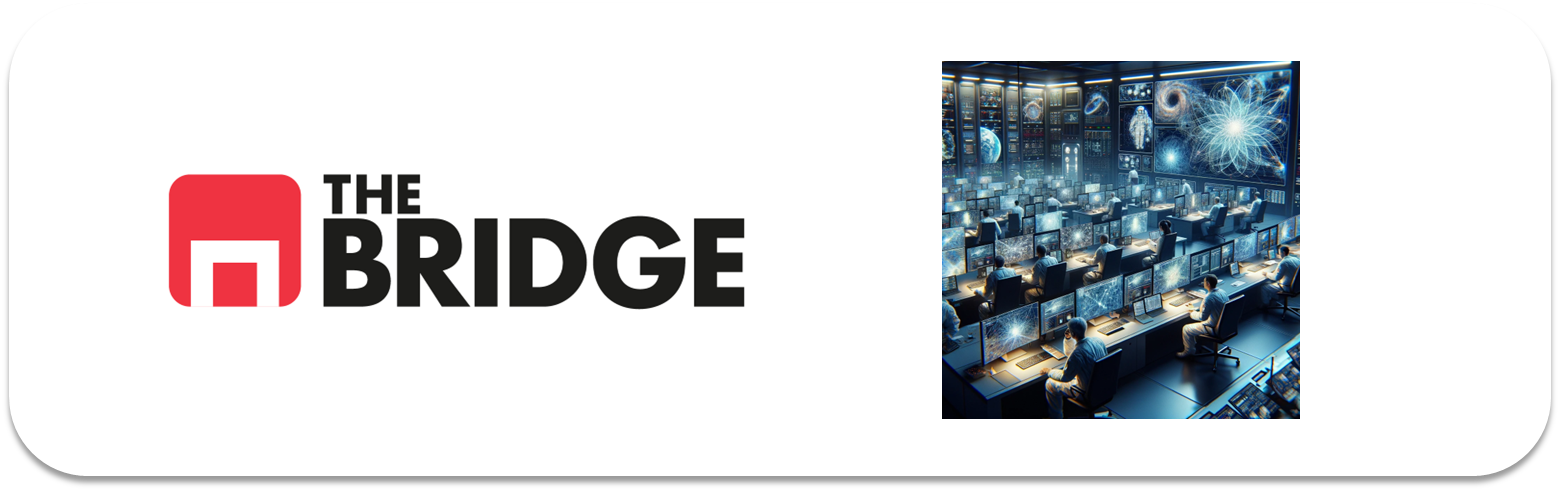

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
import cv2
import keras
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

from skimage.io import imread
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from time import time

import gc 

pd.options.mode.copy_on_write = True

C:\Users\maria\AppData\Local\Temp\ipykernel_7516\2258367956.py:16: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = True


In [3]:
import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.gpu_device_name())

Num GPUs Available:  0



In [4]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import kagglehub

path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

c:\Users\maria\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\maria\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2


### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.





In [6]:
ROOT_PATH = path

In [7]:
path

'C:\\Users\\maria\\.cache\\kagglehub\\datasets\\puneet6060\\intel-image-classification\\versions\\2'

In [8]:
import os
os.listdir(path)

['seg_pred', 'seg_test', 'seg_train']

In [9]:
os.listdir(path + "/seg_train/seg_train/")

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [10]:
### Carga de datos y preparación obtenidas del ejercicio de la unidad 1:
# ROOT_PATH = './data/'
TRAIN_PATH = ROOT_PATH + "/seg_train/seg_train/"
TEST_PATH = ROOT_PATH + "/seg_test/seg_test/"

In [11]:
os.listdir(TRAIN_PATH)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [12]:
os.listdir(TEST_PATH)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

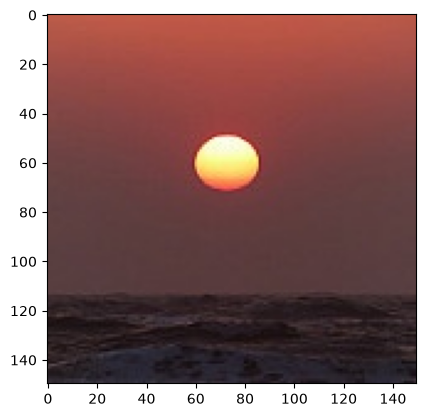

In [13]:
plt.imshow(imread(TRAIN_PATH + "/sea/"+ "11321.jpg"))
plt.show()

In [14]:
imread(TRAIN_PATH + "/sea/"+ "11321.jpg").shape

(150, 150, 3)

In [15]:
IMG_WIDTH = IMG_HEIGHT = 75

In [16]:
def read_data(directorio, reshape_dim = (IMG_WIDTH,IMG_HEIGHT)):
    X = []
    y = []
    for folder in os.listdir(directorio):
        print(folder)
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):

                image = imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim) # Redimensionamos las imágenes a 75x75

                X.append(image)
                y.append(folder)

    return np.array(X),np.array(y)

def show_images_batch(paisajes, names = [], n_cols = 5, size_scale = 2):
    n_rows = ((len(paisajes) - 1) // n_cols + 1)
    plt.figure(figsize=(n_cols * size_scale, n_rows * 1.1*size_scale))
    for index, paisaje in enumerate(paisajes):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(paisaje, cmap = "Greys")
        plt.axis("off")
        if len(names):
            plt.title(names[index])

In [17]:
X_train, y_train = read_data(TRAIN_PATH)
X_test, y_test = read_data(TEST_PATH)

buildings
forest
glacier
mountain
sea
street
buildings
forest
glacier
mountain
sea
street


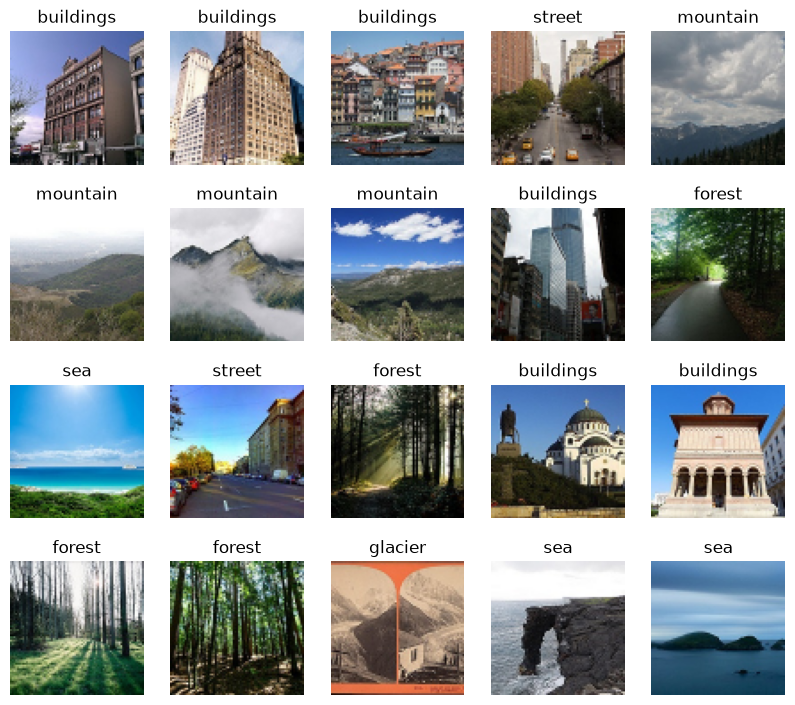

In [18]:
indices = np.random.randint(0,len(X_train),20)
show_images_batch(X_train[indices], names = y_train[indices], n_cols = 5)

In [19]:
X_train.shape

(14034, 75, 75, 3)

In [20]:
X_train.size

236823750

In [21]:
X_test.shape

(3000, 75, 75, 3)

In [22]:
pd.Series(y_train).value_counts(normalize=True)

mountain     0.178994
glacier      0.171298
street       0.169731
sea          0.162035
forest       0.161821
buildings    0.156121
Name: proportion, dtype: float64

In [23]:
X_train = (X_train/127.5) - 1.0
X_test = (X_test/127.5) - 1.0

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.



In [24]:
# Escogemos Inception V3 
from keras.applications import InceptionV3

3. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.



In [25]:
temp_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(75, 75, 3))

In [26]:
temp_model.input

<KerasTensor shape=(None, 75, 75, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor>

In [27]:
temp_model.output

<KerasTensor shape=(None, 1, 1, 2048), dtype=float32, sparse=False, ragged=False, name=keras_tensor_310>

In [28]:
del temp_model
gc.collect()

819

In [29]:
IMG_WIDTH = IMG_HEIGHT = 75
# Cargamos el modelo pre-entrenado
base_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))

# Congelamos sus capas
for layer in base_model.layers:
    layer.trainable = False

# Capa de aplanado de la salida del modelo base
def prepare_model(base_model = base_model): # Lo creamos así para poder reinicializarlo en cada reentrenamiento en ejercicios posteriores

    x = keras.layers.Flatten()(base_model.output)

    # Tantas unidades como el flatten de la salida de Inception -> 2048 features
    x = keras.layers.Dense(2048, activation='relu')(x)
    x = keras.layers.Dropout(rate = 0.25)(x)

    # Capa final de salida con 6 neuronas (una por clase) y activación softmax
    x = keras.layers.Dense(6, activation='softmax')(x)

    model = keras.Model(base_model.input, x)

    model.compile(
        optimizer = "adam",
        loss = 'sparse_categorical_crossentropy', # sparse -> y es un array de escalares pero hay varias categorias, y un array de vectores
        metrics = ['acc']
        )

    return model

# Observamos la arquitectura del modelo
model = prepare_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 75, 75, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 37, 37,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 37,    │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 37, 37,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 35, 35,    │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 35, 35,    │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 17, 17,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 17, 17,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 17,    │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 17, 17,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 15, 15,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 15, 15,    │          0 │ batch_normalizat

 Total params: 26,011,430 (99.23 MB)

 Trainable params: 4,208,646 (16.05 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [30]:
X_train.shape[0]*0.8

11227.2

In [31]:
instancias_train = len(X_train)

for i in range(1,5):
    print(f"Batch_size: {32*i}, num_steps_per_epoch: {round(instancias_train*0.8/(32*i))}")

Batch_size: 32, num_steps_per_epoch: 351
Batch_size: 64, num_steps_per_epoch: 175
Batch_size: 96, num_steps_per_epoch: 117
Batch_size: 128, num_steps_per_epoch: 88


In [32]:
y_train

array(['buildings', 'buildings', 'buildings', ..., 'street', 'street',
       'street'], shape=(14034,), dtype='<U9')

In [33]:
targets = pd.Series(y_train)

In [34]:
mapa = {tipo:indice for indice,tipo in enumerate(targets.unique())} # Reutilizando la serie que creamos para ver la distribución del target
mapa

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

In [35]:
y_train_num = np.array([mapa[y] for y in y_train])
y_test_num = np.array([mapa[y] for y in y_test])

In [36]:
y_train_num

array([0, 0, 0, ..., 5, 5, 5], shape=(14034,))

In [37]:
from sklearn.utils import shuffle
X_train_s, y_train_s = shuffle(X_train, y_train_num)

In [38]:
 from time import time

 for batch_size in [32,64,96,128]:
     t_zero = time()
     model = prepare_model()
     model.fit(X_train,
               y_train_num,
               batch_size = batch_size,
               validation_split=0.2,
               epochs=1)
     tiempo = round(time() - t_zero, 3)

     del model
     gc.collect()

     print(f"batch_size: {batch_size}, num_steps: {len(X_train)/batch_size}, tiempo 1 epoca: {tiempo}, tiempo 20 épocas: {tiempo * 20}")


351/351 ━━━━━━━━━━━━━━━━━━━━ 74s 178ms/step - acc: 0.7616 - loss: 0.6813 - val_acc: 0.1055 - val_loss: 12.6669
batch_size: 32, num_steps: 438.5625, tiempo 1 epoca: 74.761, tiempo 20 épocas: 1495.2199999999998
176/176 ━━━━━━━━━━━━━━━━━━━━ 49s 234ms/step - acc: 0.7614 - loss: 0.6866 - val_acc: 0.1193 - val_loss: 11.6617
batch_size: 64, num_steps: 219.28125, tiempo 1 epoca: 49.452, tiempo 20 épocas: 989.04
117/117 ━━━━━━━━━━━━━━━━━━━━ 46s 319ms/step - acc: 0.7561 - loss: 0.6831 - val_acc: 0.1233 - val_loss: 13.5566
batch_size: 96, num_steps: 146.1875, tiempo 1 epoca: 46.38, tiempo 20 épocas: 927.6
88/88 ━━━━━━━━━━━━━━━━━━━━ 56s 531ms/step - acc: 0.7482 - loss: 0.7266 - val_acc: 0.1115 - val_loss: 16.0953
batch_size: 128, num_steps: 109.640625, tiempo 1 epoca: 56.363, tiempo 20 épocas: 1127.26


In [39]:
batch_size = 128

In [40]:
earlyS = keras.callbacks.EarlyStopping(patience= 10, restore_best_weights= True)

In [41]:
t_zero = time()
model = prepare_model()
history = model.fit(X_train_s,
                    y_train_s,
                    batch_size = batch_size,
                    validation_split=0.2,
                    epochs=40,
                    callbacks = [earlyS])
tiempo = round(time() - t_zero, 3)

Epoch 1/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 58s 550ms/step - acc: 0.7021 - loss: 0.9214 - val_acc: 0.7766 - val_loss: 0.6083
Epoch 2/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 42s 476ms/step - acc: 0.8239 - loss: 0.4808 - val_acc: 0.7670 - val_loss: 0.6485
Epoch 3/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 43s 487ms/step - acc: 0.8782 - loss: 0.3474 - val_acc: 0.7820 - val_loss: 0.6070
Epoch 4/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 401ms/step - acc: 0.9171 - loss: 0.2511 - val_acc: 0.7866 - val_loss: 0.6317
Epoch 5/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 34s 381ms/step - acc: 0.9499 - loss: 0.1675 - val_acc: 0.7866 - val_loss: 0.6786
Epoch 6/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 33s 374ms/step - acc: 0.9712 - loss: 0.1095 - val_acc: 0.7838 - val_loss: 0.6864
Epoch 7/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 398ms/step - acc: 0.9862 - loss: 0.0681 - val_acc: 0.7759 - val_loss: 0.7779
Epoch 8/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 34s 390ms/step - acc: 0.9933 - loss: 0.0448 - val_acc: 0.7848 - val_loss: 0.7648
Epoch 9/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 34s 384ms/

In [42]:
model.evaluate(X_test, y_test_num)

94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - acc: 0.7947 - loss: 0.5760


[0.5760309100151062, 0.7946666479110718]

In [43]:
y_pred = [np.argmax(prediction) for prediction in model.predict(X_test)]

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 112ms/step


In [44]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
inverse_map = {valor:clave for clave,valor in mapa.items()}

y_test_labels = [inverse_map[y] for y in y_test_num]
y_pred_labels = [inverse_map[y] for y in y_pred]

print(classification_report(y_test_labels, y_pred_labels))

              precision    recall  f1-score   support

   buildings       0.85      0.75      0.79       437
      forest       0.94      0.93      0.94       474
     glacier       0.78      0.66      0.71       553
    mountain       0.72      0.72      0.72       525
         sea       0.73      0.85      0.78       510
      street       0.79      0.88      0.83       501

    accuracy                           0.79      3000
   macro avg       0.80      0.80      0.80      3000
weighted avg       0.80      0.79      0.79      3000



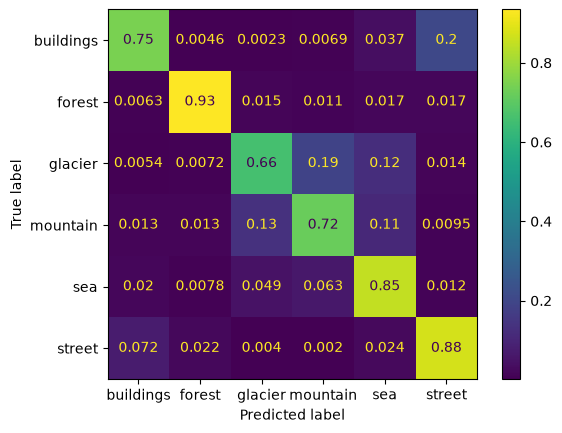

In [45]:
ConfusionMatrixDisplay.from_predictions(y_test_labels, y_pred_labels, normalize="true")
plt.show()

In [46]:
del model
del history
gc.collect()

7207

4. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.



In [47]:
base_model = InceptionV3(include_top=False, weights="imagenet", input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))

def prepare_model(base_model = base_model):
    x = keras.layers.Flatten()(base_model.output)

    x = keras.layers.Dense(2048, activation='relu')(x)
    x = keras.layers.Dropout(rate = 0.25)(x)

    x = keras.layers.Dense(6, activation='softmax')(x)

    model = keras.Model(base_model.input, x)

    model.compile(
        optimizer = "adam",
        loss = 'sparse_categorical_crossentropy',
        metrics = ['acc'])

    return model

model= prepare_model()
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 75, 75, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_188 (Conv2D) │ (None, 37, 37,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 37,    │         96 │ conv2d_188[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_188      │ (None, 37, 37,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_189 (Conv2D) │ (None, 35, 35,    │      9,216 │ activation_188[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │         96 │ conv2d_189[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_189      │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_190 (Conv2D) │ (None, 35, 35,    │     18,432 │ activation_189[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        192 │ conv2d_190[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_190      │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 17, 17,    │          0 │ activation_190[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_191 (Conv2D) │ (None, 17, 17,    │      5,120 │ max_pooling2d_8[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 17,    │        240 │ conv2d_191[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_191      │ (None, 17, 17,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_192 (Conv2D) │ (None, 15, 15,    │    138,240 │ activation_191[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        576 │ conv2d_192[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_192      │ (None, 15, 15,    │          0 │ batch_normalizat

 Total params: 26,011,430 (99.23 MB)

 Trainable params: 25,976,998 (99.09 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [49]:
 from time import time

 for batch_size in [32,64,96,128]:
     t_zero = time()
     model = prepare_model()
     model.fit(X_train_s,
               y_train_s,
               batch_size = batch_size,
               validation_split=0.2,
               epochs=1)
     tiempo = round(time() - t_zero, 3)

     del model
     gc.collect()

     print(f"batch_size: {batch_size}, num_steps: {len(X_train)/batch_size}, tiempo 1 epoca: {tiempo}, tiempo 20 épocas: {tiempo * 20}")

351/351 ━━━━━━━━━━━━━━━━━━━━ 261s 628ms/step - acc: 0.5728 - loss: 1.2672 - val_acc: 0.2490 - val_loss: 3.3595
batch_size: 32, num_steps: 438.5625, tiempo 1 epoca: 261.965, tiempo 20 épocas: 5239.299999999999
176/176 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - acc: 0.6250 - loss: 1.2476 - val_acc: 0.5550 - val_loss: 129.9298
batch_size: 64, num_steps: 219.28125, tiempo 1 epoca: 215.585, tiempo 20 épocas: 4311.7
117/117 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - acc: 0.7111 - loss: 0.9741 - val_acc: 0.5383 - val_loss: 581.2887
batch_size: 96, num_steps: 146.1875, tiempo 1 epoca: 212.451, tiempo 20 épocas: 4249.0199999999995
88/88 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - acc: 0.7828 - loss: 0.7491 - val_acc: 0.7706 - val_loss: 5.7917
batch_size: 128, num_steps: 109.640625, tiempo 1 epoca: 212.963, tiempo 20 épocas: 4259.26


In [50]:
t_zero = time()
model = prepare_model()
history = model.fit(X_train_s,
                    y_train_s,
                    batch_size = batch_size,
                    validation_split=0.2,
                    epochs=40,
                    callbacks = [earlyS])
tiempo = round(time() - t_zero, 3)

Epoch 1/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - acc: 0.8158 - loss: 0.6157 - val_acc: 0.7257 - val_loss: 0.8078
Epoch 2/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - acc: 0.8564 - loss: 0.4375 - val_acc: 0.7873 - val_loss: 0.6737
Epoch 3/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - acc: 0.8711 - loss: 0.3859 - val_acc: 0.7880 - val_loss: 0.6473
Epoch 4/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 223s 3s/step - acc: 0.8798 - loss: 0.3633 - val_acc: 0.7392 - val_loss: 0.9296
Epoch 5/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 242s 3s/step - acc: 0.9061 - loss: 0.2826 - val_acc: 0.8215 - val_loss: 0.6076
Epoch 6/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 242s 3s/step - acc: 0.9123 - loss: 0.2483 - val_acc: 0.8258 - val_loss: 0.6788
Epoch 7/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 230s 3s/step - acc: 0.9207 - loss: 0.2387 - val_acc: 0.8023 - val_loss: 0.8705
Epoch 8/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - acc: 0.9329 - loss: 0.1953 - val_acc: 0.7524 - val_loss: 1.0619
Epoch 9/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - acc: 0.9294

No sé qué he hecho para que me tarde tanto DIOS

In [51]:
model.evaluate(X_test,y_test_num)

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - acc: 0.8750 - loss: 0.5076


[0.5076133012771606, 0.875]

In [52]:
y_pred = [ np.argmax(prediction) for prediction in model.predict(X_test)]

94/94 ━━━━━━━━━━━━━━━━━━━━ 16s 142ms/step


In [53]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
inverse_map = {valor:clave for clave,valor in mapa.items()}
y_test_labels = [inverse_map[y] for y in y_test_num]
y_pred_labels = [inverse_map[y] for y in y_pred]
print(classification_report(y_test_labels, y_pred_labels))

              precision    recall  f1-score   support

   buildings       0.91      0.85      0.88       437
      forest       0.96      0.97      0.97       474
     glacier       0.76      0.89      0.82       553
    mountain       0.86      0.77      0.81       525
         sea       0.89      0.89      0.89       510
      street       0.91      0.88      0.90       501

    accuracy                           0.88      3000
   macro avg       0.88      0.88      0.88      3000
weighted avg       0.88      0.88      0.88      3000



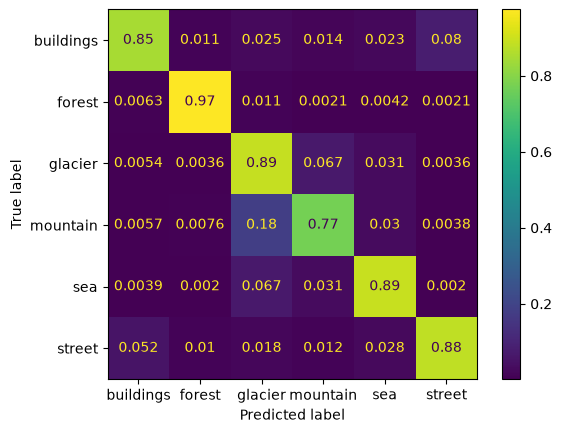

In [54]:
ConfusionMatrixDisplay.from_predictions(y_test_labels, y_pred_labels, normalize="true")
plt.show()

5. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

Respuesta: El modelo nuevo es mejor que el primero en casi todos los parámetros.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.

In [55]:
ficheros = []
clases = []
for directorio in os.listdir(TRAIN_PATH):
    clase = directorio
    ficher = [TRAIN_PATH + directorio + "/" + fichero for fichero in os.listdir(TRAIN_PATH + directorio)]
    clases += [clase for fichero in ficher]
    ficheros += ficher
train_augmented = pd.DataFrame({"filename": ficheros,"category": clases})
train_augmented.head(10)

,filename,category
0,C:\Users\maria\.cache\kagglehub\datasets\punee...,buildings
1,C:\Users\maria\.cache\kagglehub\datasets\punee...,buildings
2,C:\Users\maria\.cache\kagglehub\datasets\punee...,buildings
3,C:\Users\maria\.cache\kagglehub\datasets\punee...,buildings
4,C:\Users\maria\.cache\kagglehub\datasets\punee...,buildings
5,C:\Users\maria\.cache\kagglehub\datasets\punee...,buildings
6,C:\Users\maria\.cache\kagglehub\datasets\punee...,buildings
7,C:\Users\maria\.cache\kagglehub\datasets\punee...,buildings
8,C:\Users\maria\.cache\kagglehub\datasets\punee...,buildings
9,C:\Users\maria\.cache\kagglehub\datasets\punee...,buildings


In [56]:
def prep_fn(img):
  img = img.astype(np.float32) / 255.0
  img = (img - 0.5) * 2
  return img

In [57]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=15,
    rescale=1./255,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

In [58]:
train_df, validate_df = train_test_split(train_augmented,
                                         test_size=0.20,
                                         stratify=train_augmented['category'],
                                         random_state=42)

In [59]:
train_df.head()

,filename,category
909,C:\Users\maria\.cache\kagglehub\datasets\punee...,buildings
11104,C:\Users\maria\.cache\kagglehub\datasets\punee...,sea
5212,C:\Users\maria\.cache\kagglehub\datasets\punee...,glacier
5378,C:\Users\maria\.cache\kagglehub\datasets\punee...,glacier
2262,C:\Users\maria\.cache\kagglehub\datasets\punee...,forest


In [60]:
validate_df.head()

,filename,category
3387,C:\Users\maria\.cache\kagglehub\datasets\punee...,forest
6290,C:\Users\maria\.cache\kagglehub\datasets\punee...,glacier
8662,C:\Users\maria\.cache\kagglehub\datasets\punee...,mountain
379,C:\Users\maria\.cache\kagglehub\datasets\punee...,buildings
1951,C:\Users\maria\.cache\kagglehub\datasets\punee...,buildings


In [61]:
train_df = train_df.reset_index(drop=True)
validate_df = validate_df.reset_index(drop=True)

In [62]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='category',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    class_mode='sparse',
    batch_size= batch_size
)

Found 11227 validated image filenames belonging to 6 classes.


In [63]:
validation_datagen = ImageDataGenerator(rescale=1./255)

validation_generator = validation_datagen.flow_from_dataframe(
    validate_df,
    x_col='filename',
    y_col='category',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    class_mode='sparse',
    batch_size= batch_size
)

Found 2807 validated image filenames belonging to 6 classes.


In [64]:
from keras.applications import InceptionV3

base_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))

for layer in base_model.layers:
    layer.trainable = False

def prepare_model(base_model = base_model):
    x = keras.layers.Flatten()(base_model.output)

    x = keras.layers.Dense(2048, activation='relu')(x)
    x = keras.layers.Dropout(rate = 0.25)(x)

    x = keras.layers.Dense(6, activation='softmax')(x)

    model = keras.Model(base_model.input, x)

    model.compile(
        optimizer = "adam",
        loss = 'sparse_categorical_crossentropy',
        metrics = ['acc']
        )

    return model

In [65]:
model = prepare_model()
history = model.fit(
    train_generator,
    epochs= 40,
    validation_data=validation_generator,
    callbacks= earlyS
)

Epoch 1/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 73s 746ms/step - acc: 0.6500 - loss: 0.9796 - val_acc: 0.7467 - val_loss: 0.6952
Epoch 2/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 56s 630ms/step - acc: 0.7345 - loss: 0.7219 - val_acc: 0.7481 - val_loss: 0.6673
Epoch 3/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 56s 638ms/step - acc: 0.7480 - loss: 0.6798 - val_acc: 0.7606 - val_loss: 0.6404
Epoch 4/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 56s 636ms/step - acc: 0.7617 - loss: 0.6421 - val_acc: 0.7734 - val_loss: 0.6213
Epoch 5/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 59s 666ms/step - acc: 0.7617 - loss: 0.6315 - val_acc: 0.7695 - val_loss: 0.6311
Epoch 6/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 56s 640ms/step - acc: 0.7660 - loss: 0.6287 - val_acc: 0.7788 - val_loss: 0.6134
Epoch 7/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 62s 702ms/step - acc: 0.7706 - loss: 0.6093 - val_acc: 0.7781 - val_loss: 0.5945
Epoch 8/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 62s 706ms/step - acc: 0.7769 - loss: 0.5939 - val_acc: 0.7773 - val_loss: 0.5927
Epoch 9/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 63s 715ms/

In [66]:
model.evaluate(X_test,y_test_num)

94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 124ms/step - acc: 0.7877 - loss: 0.5613


[0.5613196492195129, 0.7876666784286499]

In [67]:
validation_generator.class_indices

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

In [68]:
mapa

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

In [69]:
y_test_num = np.array([validation_generator.class_indices[y] for y in y_test])

In [70]:
model.evaluate(X_test,y_test_num)

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - acc: 0.7877 - loss: 0.5613


[0.5613196492195129, 0.7876666784286499]

In [71]:
y_pred = [ np.argmax(prediction) for prediction in model.predict(X_test)]

94/94 ━━━━━━━━━━━━━━━━━━━━ 16s 147ms/step


In [72]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
inverse_map = {valor:clave for clave,valor in validation_generator.class_indices.items()}
y_test_labels = [inverse_map[y] for y in y_test_num]
y_pred_labels = [inverse_map[y] for y in y_pred]
print(classification_report(y_test_labels, y_pred_labels))

              precision    recall  f1-score   support

   buildings       0.81      0.79      0.80       437
      forest       0.92      0.95      0.93       474
     glacier       0.75      0.70      0.73       553
    mountain       0.70      0.67      0.68       525
         sea       0.77      0.79      0.78       510
      street       0.78      0.85      0.82       501

    accuracy                           0.79      3000
   macro avg       0.79      0.79      0.79      3000
weighted avg       0.79      0.79      0.79      3000



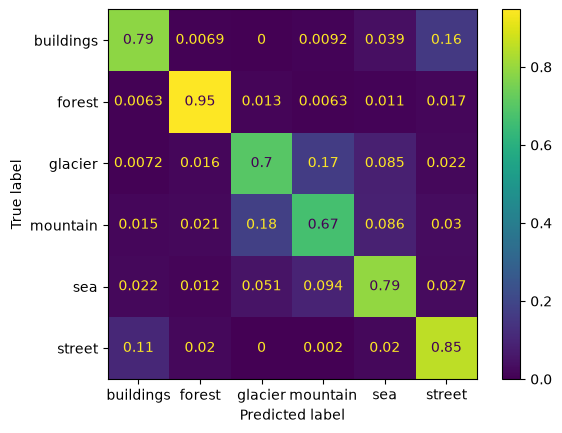

In [73]:
ConfusionMatrixDisplay.from_predictions(y_test_labels, y_pred_labels, normalize="true")
plt.show()